Attributing Star Luminosities

In [1]:
import numpy as np
import os
import yt
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt 
import pandas as pd

*** WARNING (KS MODIFIED) ****   particle_families is modified in yt/frontends/ramses/definitions.py


In [4]:
FIELDS = ["Density",
          "x-velocity", "y-velocity", "z-velocity",
          "Pressure",
          "Metallicity",
          "dark_matter_density",
          "xHI", "xHII", "xHeII", "xHeIII"]
#extra particle fields
EPF= [('particle_family', 'b'),      
      ('particle_tag', 'b'),         
      ('particle_birth_epoch', 'd'), 
      ('particle_metallicity', 'd')] 
datadir = os.path.expanduser(
    'G:/My Drive/Research/AstrophysicsSimulation/DesktopEnvironment/data_globular_cluster/refine/output_00250/info_00250.txt') 
ds = yt.load(datadir, fields=FIELDS, extra_particle_fields=EPF)

ad = ds.all_data()
be_star=ad['star', 'particle_birth_epoch'] #birth_epoch of star (Pop II stars)

yt : [INFO     ] 2021-12-27 21:20:35,976 Parameters: current_time              = 4.447736216918125
yt : [INFO     ] 2021-12-27 21:20:35,977 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2021-12-27 21:20:35,977 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2021-12-27 21:20:35,978 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2021-12-27 21:20:35,979 Parameters: cosmological_simulation   = 1
yt : [INFO     ] 2021-12-27 21:20:35,980 Parameters: current_redshift          = 11.056738498661748
yt : [INFO     ] 2021-12-27 21:20:35,981 Parameters: omega_lambda              = 0.730000019073486
yt : [INFO     ] 2021-12-27 21:20:35,982 Parameters: omega_matter              = 0.270000010728836
yt : [INFO     ] 2021-12-27 21:20:35,983 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2021-12-27 21:20:35,984 Parameters: hubble_constant           = 0.7
yt : [WARNING  ] 2021-12-27 21:20:36,009 Detected 1 extra gravity fields.


In [85]:
def code_age_to_yr (all_star_ages, hubble_const, unique = True): 
    r"""
    Returns an array with unique birth epochs in Myr given  
    raw_birth_epochs = ad['star', 'particle_birth_epoch'] 
    AND 
    hubble = ds.hubble_constant  
    Youngest is 0 Myr, all others are relative to the youngest.
    """
    cgs_yr = 3.1556926e7              # 1yr (in s)
    cgs_pc = 3.08568e18               # pc (in cm)
    h_0 =  hubble_const*100           # hubble parameter (km/s/Mpc)
    h_0_invsec = h_0*1e5/(1e6*cgs_pc) # hubble constant h [km/s Mpc-1]->[1/sec]
    h_0inv_yr = 1/h_0_invsec/cgs_yr   # 1/h_0 [yr]
    
    if unique == True:
        #process to unique birth epochs only
        be_star_processed = np.array(sorted( list( set(all_star_ages.to_ndarray()) ) ) ) 
        star_age_myr = be_star_processed*h_0inv_yr/1e6
        relative_ages = star_age_myr - star_age_myr.min()
        #print(star_age_myr)
    else: 
        all_stars  =  all_star_ages
        star_age_myr = all_stars*h_0inv_yr/1e6
        relative_ages = star_age_myr - star_age_myr.min()
        #print(star_age_myr.min())
        #print(star_age_myr) # correspond to current time in code time
    return relative_ages

converted = code_age_to_yr (be_star, ds.hubble_constant, unique=True)
offset = converted + 339.562
print(offset)
current_age = float(ds.current_time.in_units('Myr'))
print(current_age)
test = current_age - offset
print(test)

[339.562      358.08973269 375.17095952 408.2394688  408.52589576
 408.66089334 408.90619314 409.73592563 409.75919182 409.7647757
 409.86422356 409.97987201 410.35623501]
426.6070703354823
[87.04507034 68.51733764 51.43611082 18.36760154 18.08117457 17.946177
 17.7008772  16.8711447  16.84787852 16.84229463 16.74284678 16.62719832
 16.25083533]


In [73]:
# [-13526.15514609 -13507.6274134  -13490.54618658 -13457.47767729
#  -13457.19125033 -13457.05625276 -13456.81095295 -13455.98122046
#  -13455.95795428 -13455.95237039 -13455.85292254 -13455.73727408
#  -13455.36091108]
62129.40245474353 - 13455.36091108

48674.04154366353

In [16]:
pop_2_data = np.loadtxt(r"star_positions_out400.txt") 
ages = pop_2_data[:,0] *1e6 # yr
x_pos = pop_2_data[:,1]
y_pos = pop_2_data[:,2] 
xlim = -125, 125
ylim = -125, 125

### Just doing raw counts

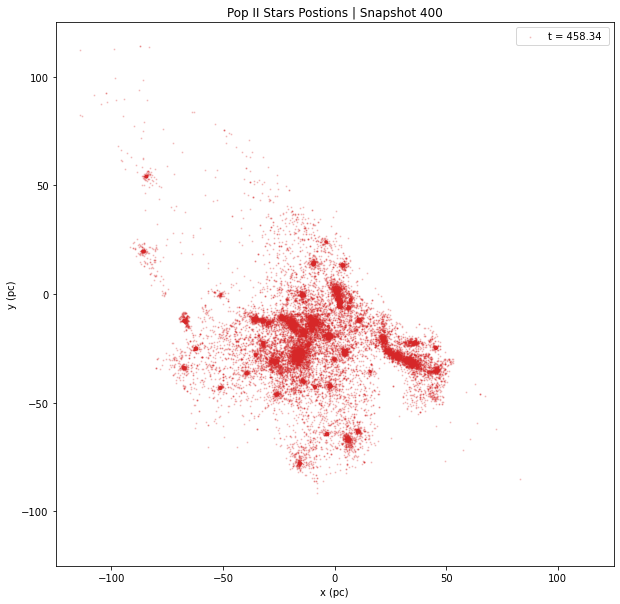

In [3]:
plt.figure(figsize = (10,10)) 

plt.scatter(x_pos, y_pos, s=1, c='tab:red', alpha=.2, label='t = 458.34 ')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("Pop II Stars Postions | Snapshot 400")
plt.xlabel("x (pc)")
plt.ylabel("y (pc)")
plt.legend()

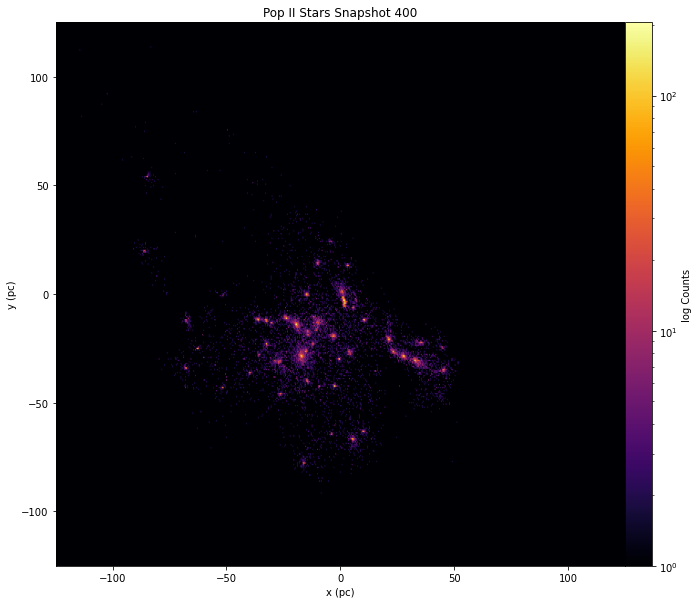

In [63]:
plt.figure(figsize = (12,10), )
log_scale = plt.hexbin(x_pos, y_pos, gridsize=1000, cmap='inferno', bins='log', extent=[-200, 200, -200, 200])
plt.xlim(-125, 125)
plt.ylim(-125, 125)
plt.title("Pop II Stars Snapshot 400")
plt.xlabel("x (pc)")
plt.ylabel("y (pc)")
plt.colorbar(log_scale, label='log Counts', pad = 0)

In [5]:
pixel_values = log_scale.get_array() 
positons = log_scale.get_offsets() 
x = positons[:,0]
y = positons[:,1]

1155578


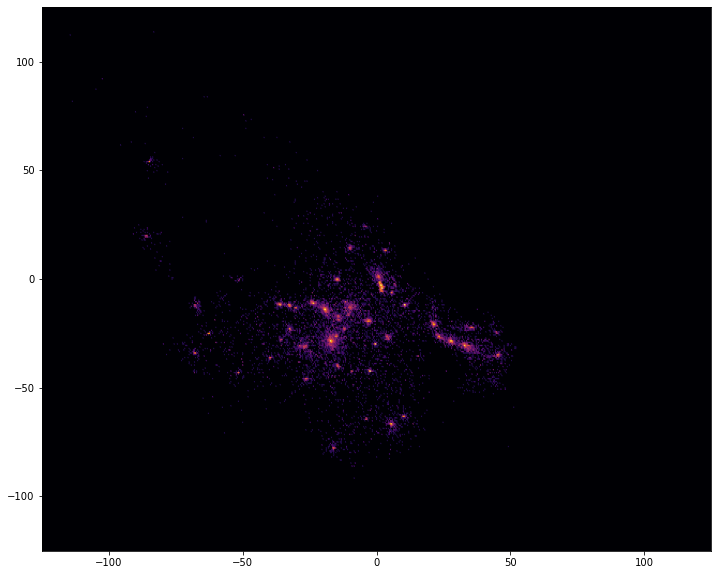

In [40]:
plt.figure(figsize = (12,10), )
plt.hexbin(x , y, pixel_values, cmap='inferno', bins='log', gridsize=1000)
plt.xlim(-125, 125)
plt.ylim(-125, 125)

In [74]:
print(x.size)

1155578


In [8]:
df = pd.read_csv('https://www.stsci.edu/science/starburst99/data/l1500_inst_e.dat', delim_whitespace=True, header=None)
data = df.to_numpy().astype(float)
time = data[:,0]
lum = data[:,2] 

In [9]:
def power_law(time, a, exp):
    lum = a * time**exp
    return lum

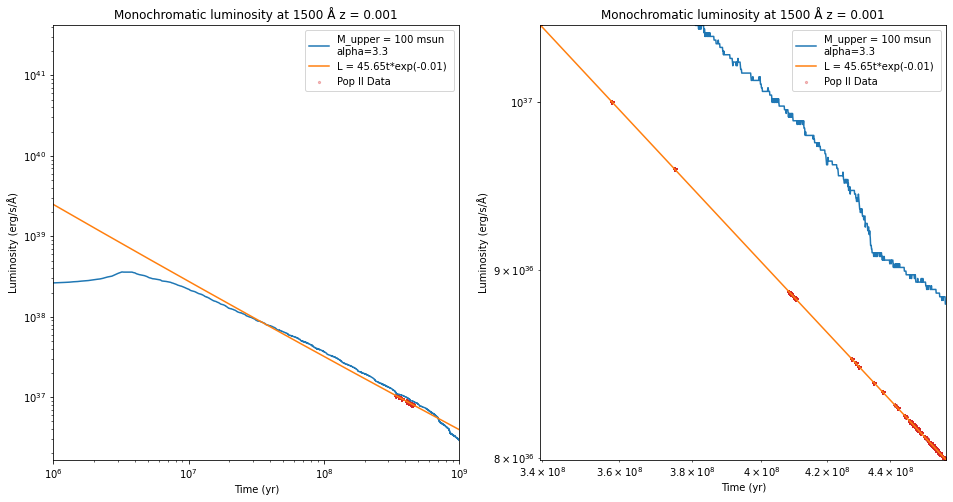

In [57]:
plt.figure(figsize = (16,8), )
plt.subplot(1, 2, 1)
plt.plot(time, 10**lum, label='M_upper = 100 msun  \nalpha=3.3')
mask = time > 6.5e6
par, cov = curve_fit(power_law, time, lum) 
plt.plot(time, 10**power_law(time, *par), label = r'L = {:.2f}t*exp({:.2f})'.format(par[0], par[1]))
stellar_lums = 10**power_law(ages,*par )
plt.scatter(ages, staller_lums, s= 5, alpha = .3, c='tab:red', label='Pop II Data')
plt.xlim(1e6,1e9)
plt.xscale('log')
plt.yscale('log')
plt.title("Monochromatic luminosity at 1500 Å z = 0.001")
plt.xlabel("Time (yr)")
plt.ylabel("Luminosity (erg/s/Å)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(time, 10**lum, label='M_upper = 100 msun  \nalpha=3.3')
plt.plot(time, 10**(power_law(time, *par)), label = r'L = {:.2f}t*exp({:.2f})'.format(par[0], par[1]))

stellar_lums = 10**(power_law(ages,*par ))

plt.scatter(ages, stellar_lums, s= 5, alpha = .3, c='tab:red', label='Pop II Data')
plt.xlim(np.min(ages),np.max(ages))
plt.ylim(np.min(stellar_lums)-1e11, np.max(stellar_lums)+1e11 )

plt.xscale('log')
plt.yscale('log')
plt.title("Monochromatic luminosity at 1500 Å z = 0.001")
plt.xlabel("Time (yr)")
plt.ylabel("Luminosity (erg/s/Å)")
plt.legend()


# You are doing birth epochs not ages

(-100.0, 100.0)

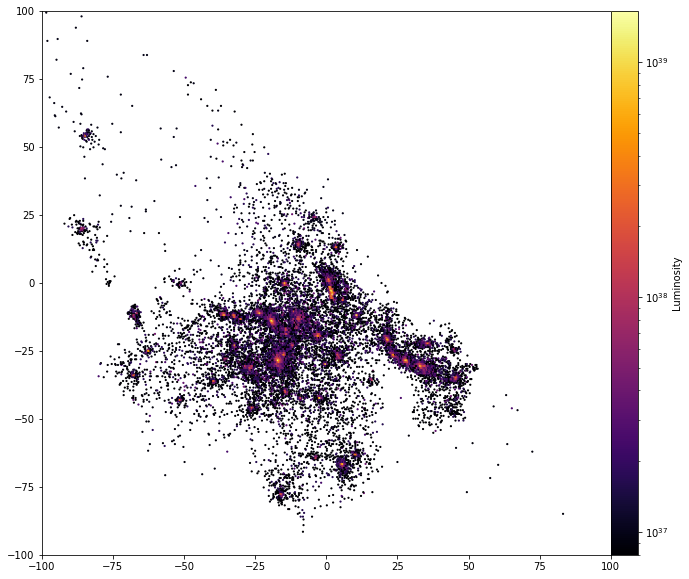

In [93]:
plt.figure(figsize = (12,10), )
test = plt.hexbin(x_pos, y_pos, stellar_lums,
                  gridsize=1000, 
                  cmap='inferno',
                  bins='log', 
                  extent=[-200, 200, -200, 200], reduce_C_function=np.sum)
plt.colorbar(test, label='Luminosity', pad = 0)
plt.xlim(-100, 100)
plt.ylim(-100, 100)

In [72]:
pixel_values = test.get_array() 
positons = test.get_offsets() 
testx = positons[:,0]
testy = positons[:,1]

In [89]:
print(x_pos.size)

34861


In [79]:
np.min(stellar_lums)

7.988939023876551e+36